# SHBT 261 AI in Medicine Mini Project 1

**Harvard University**\
**Spring 2026**\
**Instructors**: Mengyu Wang and Tobias Elze

<hr style="height:2pt">

In [9]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from skimage.feature import hog
from skimage.transform import resize as sk_resize
from skimage.color import rgb2gray
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

Found 102 classes
First 10: ['BACKGROUND_Google', 'Faces', 'Faces_easy', 'Leopards', 'Motorbikes', 'accordion', 'airplanes', 'anchor', 'ant', 'barrel']

Total images: 9144
Sample entry: (PosixPath('caltech-101/BACKGROUND_Google/image_0146.jpg'), 0, 'BACKGROUND_Google')


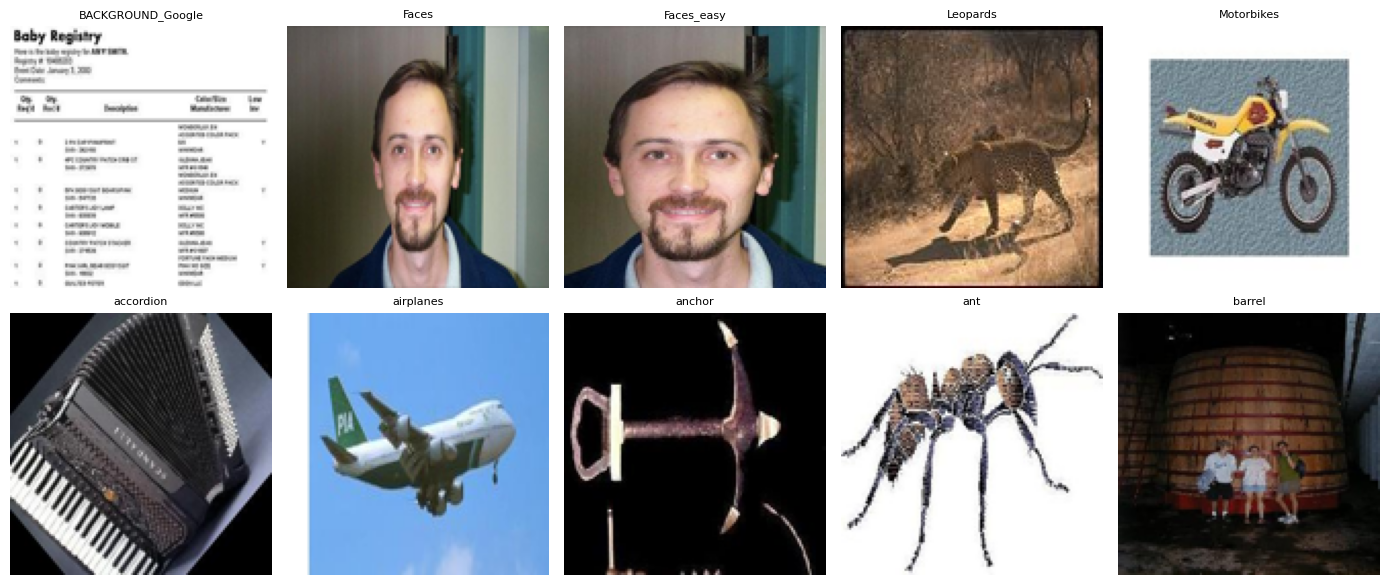

In [4]:
# ── 1. Point to your dataset root ──────────────────────────────────────────
DATA_DIR = Path("caltech-101")          # adjust if needed

# ── 2. Discover all classes (sub-folders) ──────────────────────────────────
classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
class_to_idx = {cls: i for i, cls in enumerate(classes)}

print(f"Found {len(classes)} classes")
print("First 10:", classes[:10])

# ── 3. Build a flat list of (image_path, label_index, class_name) ──────────
dataset = []
for cls in classes:
    for img_path in (DATA_DIR / cls).glob("*.jpg"):
        dataset.append((img_path, class_to_idx[cls], cls))

print(f"\nTotal images: {len(dataset)}")
print("Sample entry:", dataset[0])

# ── 4. Quick sanity check – open one image per class ──────────────────────
def load_image(path, size=(128, 128)):
    img = Image.open(path).convert("RGB").resize(size)
    return np.array(img)

# Show a few sample images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
sample_classes = classes[:10]
for ax, cls in zip(axes.flat, sample_classes):
    sample_path = next((DATA_DIR / cls).glob("*.jpg"))
    ax.imshow(load_image(sample_path))
    ax.set_title(cls, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

df = pd.DataFrame(dataset, columns=["image_path", "label_index", "class_name"])
df.head(10)

,image_path,label_index,class_name
0,caltech-101/BACKGROUND_Google/image_0146.jpg,0,BACKGROUND_Google
1,caltech-101/BACKGROUND_Google/image_0152.jpg,0,BACKGROUND_Google
2,caltech-101/BACKGROUND_Google/image_0185.jpg,0,BACKGROUND_Google
3,caltech-101/BACKGROUND_Google/image_0191.jpg,0,BACKGROUND_Google
4,caltech-101/BACKGROUND_Google/image_0378.jpg,0,BACKGROUND_Google
5,caltech-101/BACKGROUND_Google/image_0344.jpg,0,BACKGROUND_Google
6,caltech-101/BACKGROUND_Google/image_0422.jpg,0,BACKGROUND_Google
7,caltech-101/BACKGROUND_Google/image_0436.jpg,0,BACKGROUND_Google
8,caltech-101/BACKGROUND_Google/image_0350.jpg,0,BACKGROUND_Google
9,caltech-101/BACKGROUND_Google/image_0387.jpg,0,BACKGROUND_Google


In [11]:
# ── 1. Build DataFrame ─────────────────────────────────────────────────────
DATA_DIR = Path("caltech-101")

records = []
for cls_folder in sorted(DATA_DIR.iterdir()):
    if cls_folder.is_dir():
        for img_path in cls_folder.glob("*.jpg"):
            records.append({"image_path": str(img_path), "class_name": cls_folder.name})

df = pd.DataFrame(records)

# Encode string labels → integers
le = LabelEncoder()
df["label"] = le.fit_transform(df["class_name"])

print(f"Total images : {len(df)}")
print(f"Total classes: {df['label'].nunique()}")
df.head()

Total images : 9144
Total classes: 102


,image_path,class_name,label
0,caltech-101/BACKGROUND_Google/image_0146.jpg,BACKGROUND_Google,0
1,caltech-101/BACKGROUND_Google/image_0152.jpg,BACKGROUND_Google,0
2,caltech-101/BACKGROUND_Google/image_0185.jpg,BACKGROUND_Google,0
3,caltech-101/BACKGROUND_Google/image_0191.jpg,BACKGROUND_Google,0
4,caltech-101/BACKGROUND_Google/image_0378.jpg,BACKGROUND_Google,0


In [12]:
# ── 2. Stratified split 70 / 15 / 15 ──────────────────────────────────────
# First split off 70% train
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=42
)

# Split the remaining 30% equally into val and test (15% each)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df):>5} images ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val   : {len(val_df):>5} images ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test  : {len(test_df):>5} images ({len(test_df)/len(df)*100:.1f}%)")

Train :  6400 images (70.0%)
Val   :  1372 images (15.0%)
Test  :  1372 images (15.0%)


In [13]:
# ── 3a. For Classical ML → flat numpy arrays with HOG features ─────────────
IMG_SIZE = (128, 128)   # resize all images to this before HOG

def extract_hog(img_path):
    img = Image.open(img_path).convert("RGB").resize(IMG_SIZE)
    img_gray = rgb2gray(np.array(img))
    features = hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
                   cells_per_block=(2, 2), feature_vector=True)
    return features

def build_ml_arrays(dataframe):
    X, y = [], []
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        X.append(extract_hog(row["image_path"]))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

print("Extracting HOG features...")
X_train_ml, y_train_ml = build_ml_arrays(train_df)
X_val_ml,   y_val_ml   = build_ml_arrays(val_df)
X_test_ml,  y_test_ml  = build_ml_arrays(test_df)

print(f"X_train shape : {X_train_ml.shape}")   # (n_samples, n_hog_features)
print(f"X_val shape   : {X_val_ml.shape}")
print(f"X_test shape  : {X_test_ml.shape}")

Extracting HOG features...


100%|██████████████████████████████████████| 1372/1372 [00:05<00:00, 261.56it/s]

X_train shape : (6400, 8100)
X_val shape   : (1372, 8100)
X_test shape  : (1372, 8100)


In [19]:
# ── 3b. For Deep Learning → PyTorch DataLoaders ────────────────────────────
DL_IMG_SIZE = 224    # standard size for pretrained models
BATCH_SIZE  = 32

dl_transform = {
    "train": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.RandomHorizontalFlip(),          # simple augmentation
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], # ImageNet mean/std
                             [0.229, 0.224, 0.225])
    ]),
    "val_test": transforms.Compose([
        transforms.Resize((DL_IMG_SIZE, DL_IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}

class Caltech101Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, row["label"]

train_loader = DataLoader(
    Caltech101Dataset(train_df, dl_transform["train"]),
    batch_size=BATCH_SIZE, shuffle=True,  num_workers=0
)
val_loader = DataLoader(
    Caltech101Dataset(val_df,   dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)
test_loader = DataLoader(
    Caltech101Dataset(test_df,  dl_transform["val_test"]),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0
)

# Quick check
images, labels = next(iter(train_loader))
print(f"Batch shape : {images.shape}")   # (32, 3, 224, 224)
print(f"Labels shape: {labels.shape}")   # (32,)

Batch shape : torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])


## Model 1: Classical ML - SVM + HOG features

In [20]:
import os
os.makedirs("figures", exist_ok=True)

In [21]:
# ── SVM + HOG: Full Pipeline ───────────────────────────────────────────────
# Requirements: X_train_ml, y_train_ml, X_val_ml, y_val_ml, 
#               X_test_ml, y_test_ml, le  (from preprocessing cells)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, top_k_accuracy_score)

# ── 1. Scale features (critical for SVM) ──────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_ml)   # fit only on train!
X_val_sc   = scaler.transform(X_val_ml)
X_test_sc  = scaler.transform(X_test_ml)

# ── 2. Train SVM ───────────────────────────────────────────────────────────
print("Training SVM... (this may take a few minutes)")
svm = SVC(kernel="rbf", C=10, gamma="scale",
          probability=True,   # needed for top-k accuracy
          random_state=42)
svm.fit(X_train_sc, y_train_ml)
print("Done!")

Training SVM... (this may take a few minutes)
Done!


In [23]:
# Save immediately after training, just call this cell next time and do not need to rerun the previous cell
import joblib
joblib.dump(svm,    "svm_model.pkl")
joblib.dump(scaler, "svm_scaler.pkl")
print("Model saved ✓")

Model saved ✓


In [27]:
# ── 3. Predictions ─────────────────────────────────────────────────────────
y_val_pred  = svm.predict(X_val_sc)
y_test_pred = svm.predict(X_test_sc)
y_test_prob = svm.predict_proba(X_test_sc)      # for top-k

In [28]:
# ── 4. Core Metrics ────────────────────────────────────────────────────────
test_acc = accuracy_score(y_test_ml, y_test_pred)
print(f"{'='*50}")
print(f"  SVM + HOG  —  Test Results")
print(f"{'='*50}")
print(f"  Overall Accuracy : {test_acc*100:.2f}%")

# Top-5 Accuracy (optional)
top5 = top_k_accuracy_score(y_test_ml, y_test_prob, k=5)
print(f"  Top-5 Accuracy   : {top5*100:.2f}%")

# Macro & Weighted Precision / Recall / F1
print(f"\n{'─'*50}")
print(classification_report(
    y_test_ml, y_test_pred,
    target_names=le.classes_,
    digits=3,
    zero_division=0
))

  SVM + HOG  —  Test Results
  Overall Accuracy : 56.71%
  Top-5 Accuracy   : 80.47%

──────────────────────────────────────────────────
                   precision    recall  f1-score   support

BACKGROUND_Google      0.139     0.914     0.242        70
            Faces      0.742     1.000     0.852        66
       Faces_easy      1.000     0.970     0.985        66
         Leopards      0.600     0.900     0.720        30
       Motorbikes      0.992     1.000     0.996       120
        accordion      1.000     0.625     0.769         8
        airplanes      0.968     1.000     0.984       120
           anchor      0.000     0.000     0.000         6
              ant      0.000     0.000     0.000         6
           barrel      0.000     0.000     0.000         7
             bass      0.000     0.000     0.000         8
           beaver      0.000     0.000     0.000         7
        binocular      0.000     0.000     0.000         5
           bonsai      0.529     0.4

In [29]:
# ── 5. Per-class Accuracy ──────────────────────────────────────────────────
cm = confusion_matrix(y_test_ml, y_test_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

per_class_df = pd.DataFrame({
    "class"          : le.classes_,
    "per_class_acc"  : per_class_acc
}).sort_values("per_class_acc", ascending=False)

print("Top 10 best recognised classes:")
print(per_class_df.head(10).to_string(index=False))
print("\nTop 10 worst recognised classes:")
print(per_class_df.tail(10).to_string(index=False))

Top 10 best recognised classes:
            class  per_class_acc
           pagoda       1.000000
            Faces       1.000000
       Motorbikes       1.000000
         car_side       1.000000
        airplanes       1.000000
       Faces_easy       0.969697
        trilobite       0.923077
BACKGROUND_Google       0.914286
         Leopards       0.900000
      dollar_bill       0.875000

Top 10 worst recognised classes:
         class  per_class_acc
     sea_horse            0.0
      scorpion            0.0
crocodile_head            0.0
    gramophone            0.0
        camera            0.0
   ceiling_fan            0.0
         okapi            0.0
     binocular            0.0
         panda            0.0
     saxophone            0.0


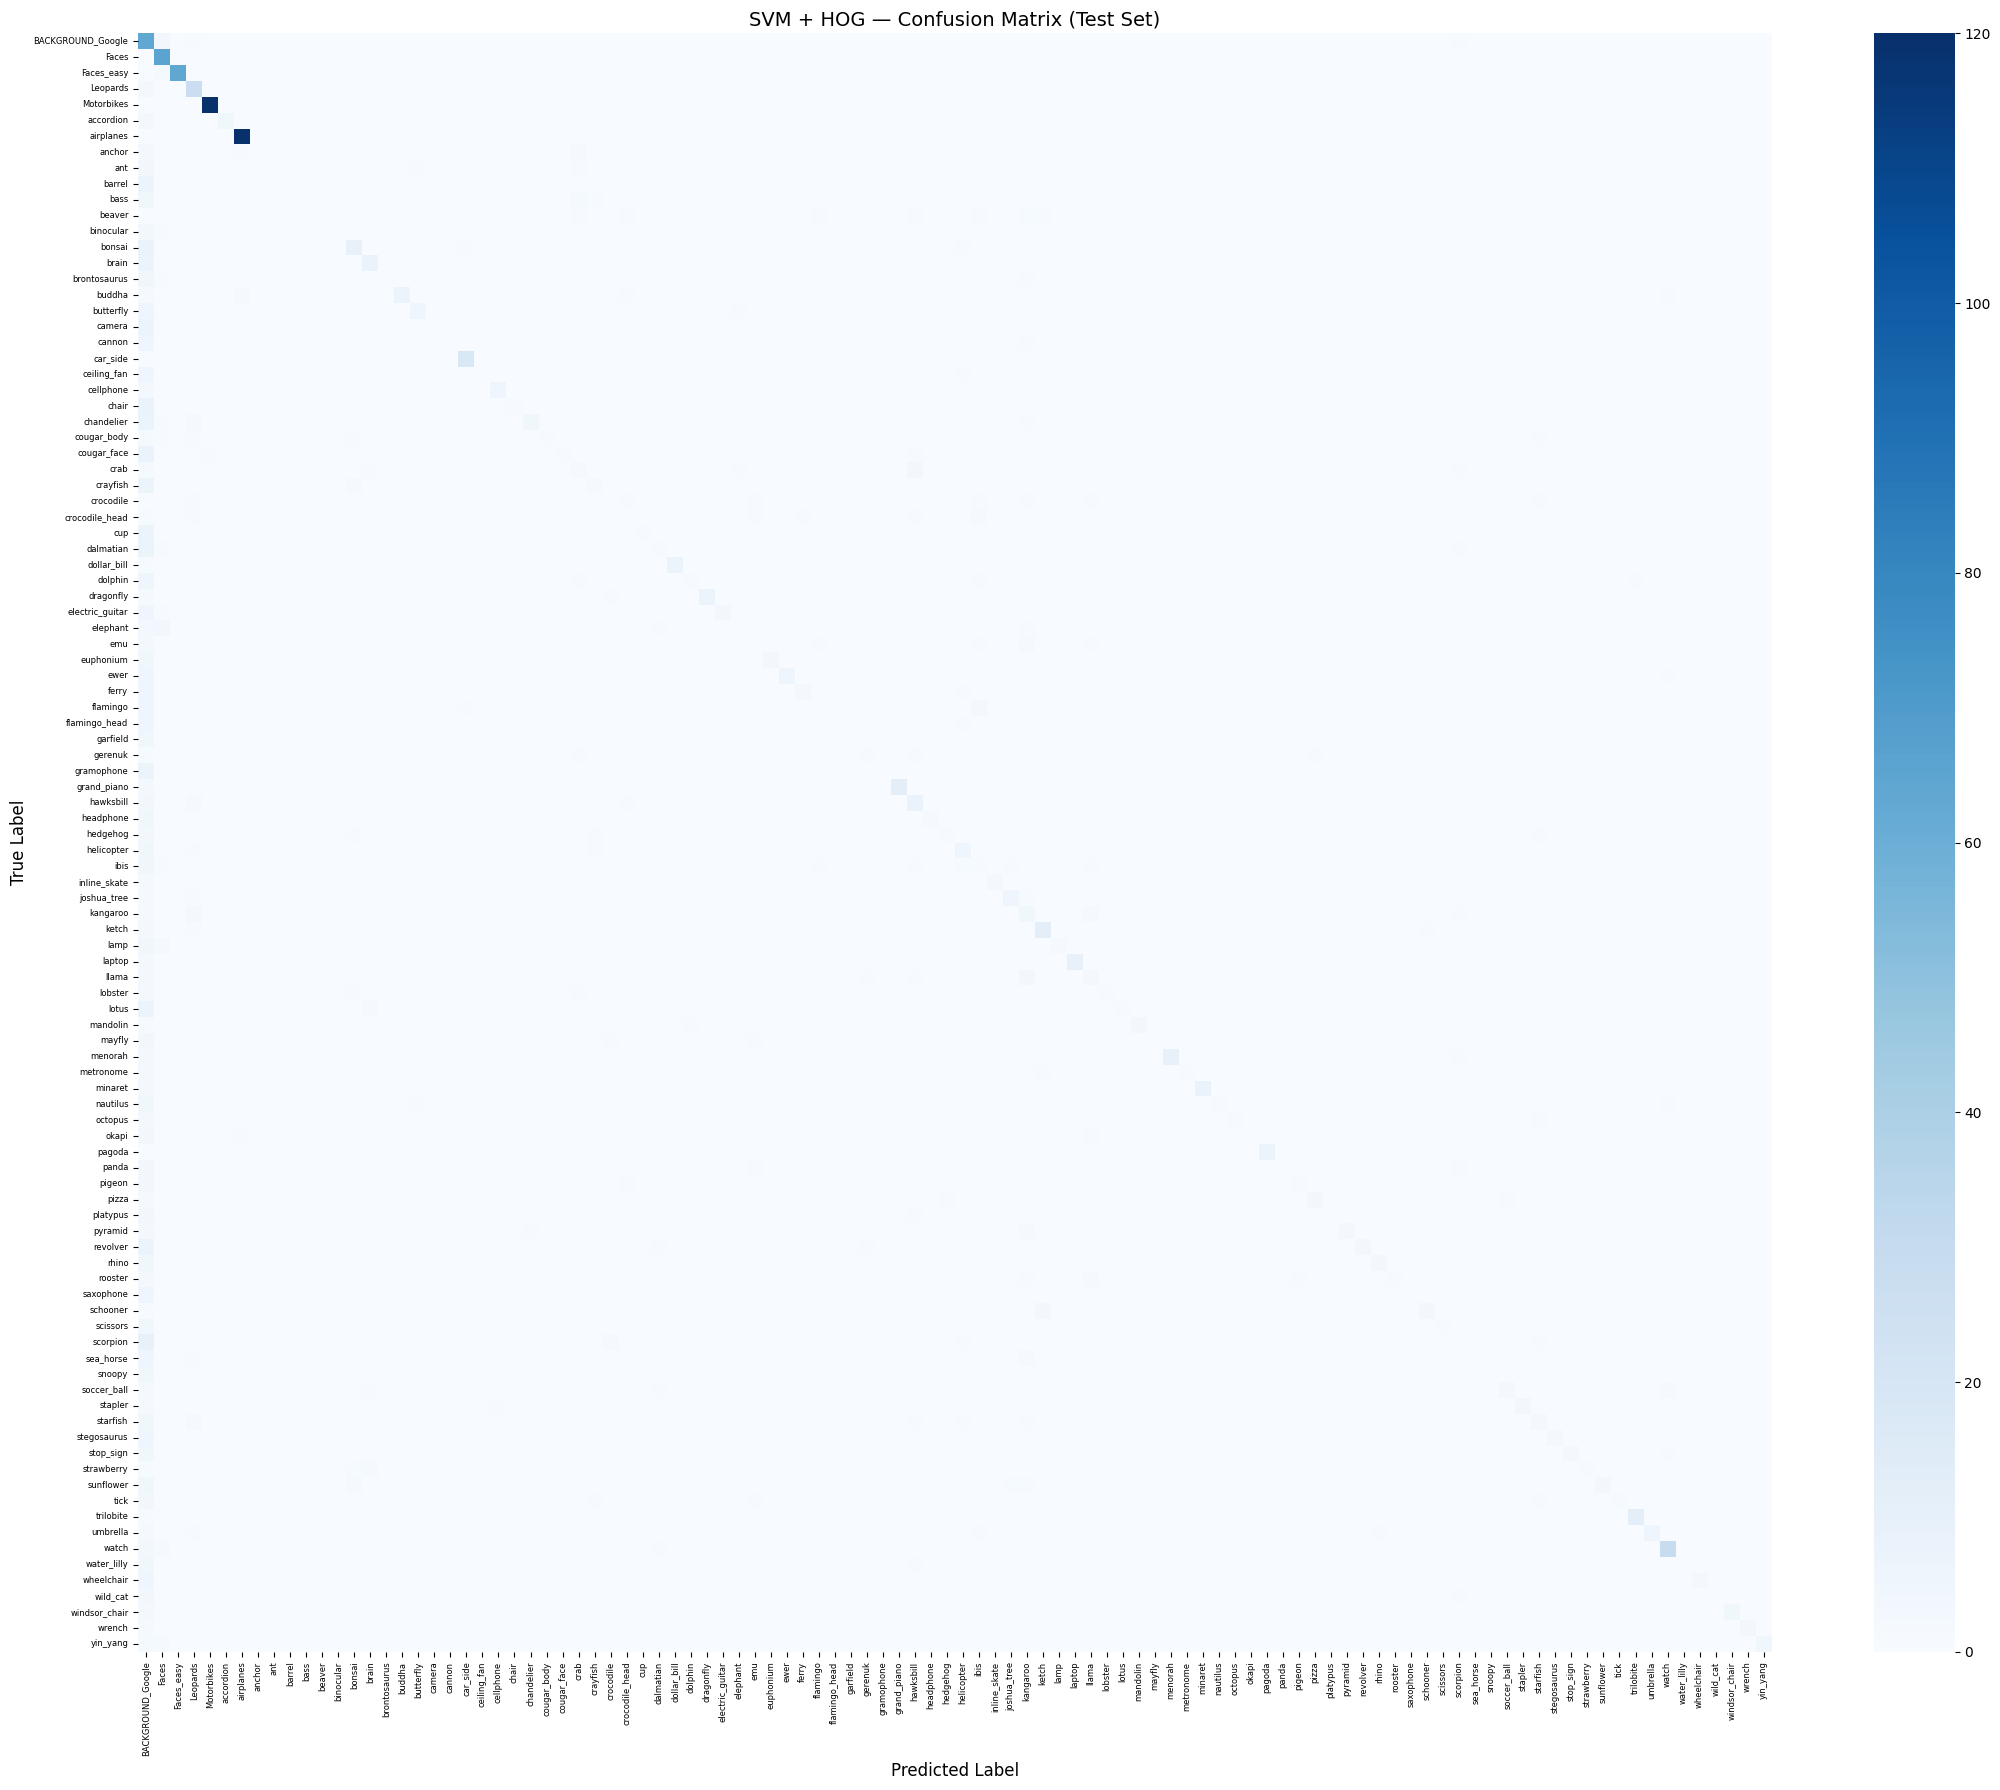

In [30]:
# ── 6. Confusion Matrix Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(cm, annot=False, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("SVM + HOG — Confusion Matrix (Test Set)", fontsize=14)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0,  fontsize=6)
plt.tight_layout()
plt.savefig("figures/svm_confusion_matrix.png", dpi=150)
plt.show()

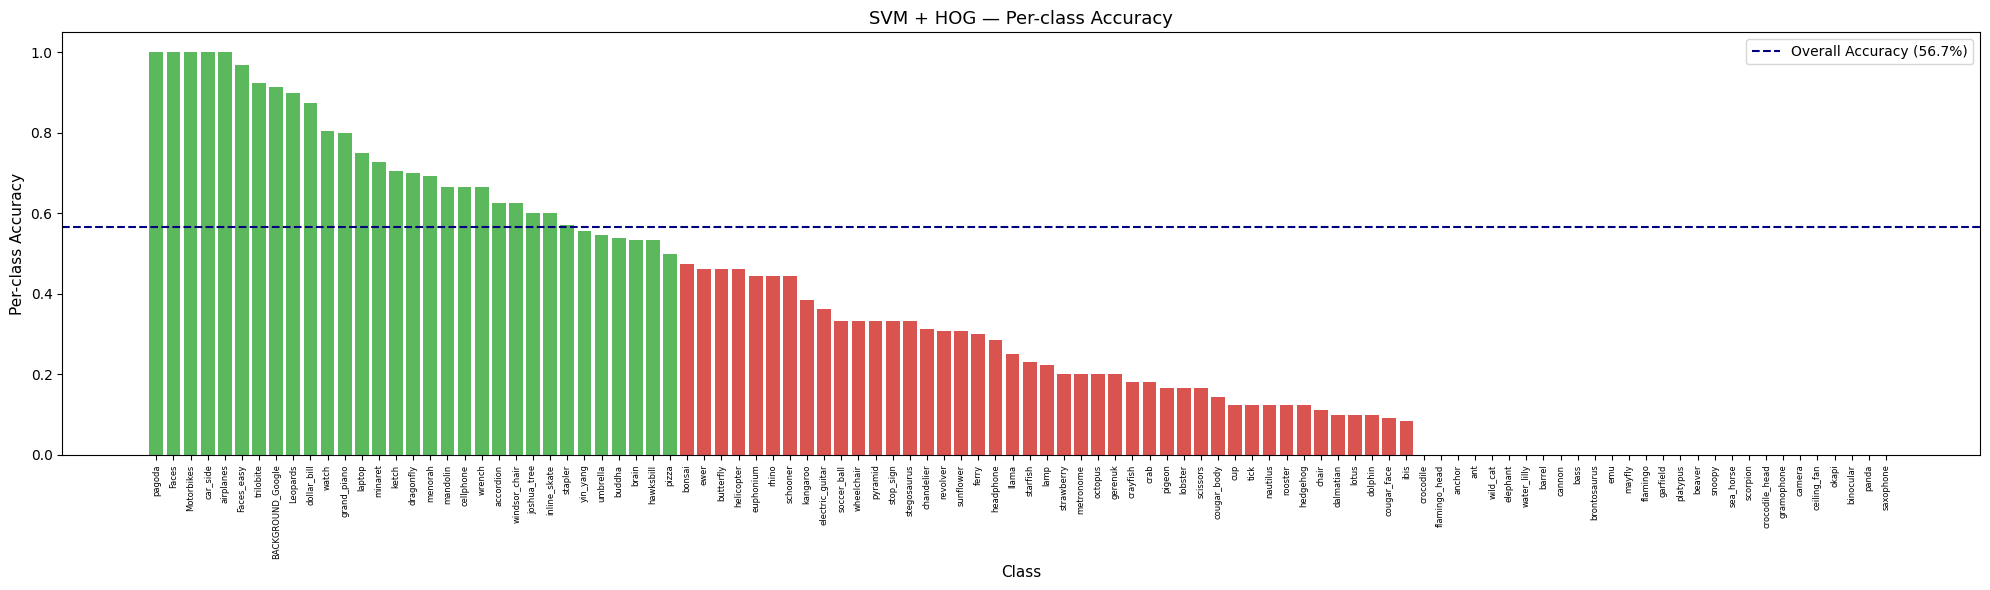

In [31]:
# ── 7. Per-class Accuracy Bar Chart ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 6))
colors = ["#d9534f" if v < 0.5 else "#5cb85c" for v in per_class_df["per_class_acc"]]
ax.bar(per_class_df["class"], per_class_df["per_class_acc"], color=colors)
ax.axhline(test_acc, color="navy", linestyle="--", linewidth=1.5,
           label=f"Overall Accuracy ({test_acc*100:.1f}%)")
ax.set_xlabel("Class", fontsize=11)
ax.set_ylabel("Per-class Accuracy", fontsize=11)
ax.set_title("SVM + HOG — Per-class Accuracy", fontsize=13)
ax.legend()
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig("figures/svm_per_class_accuracy.png", dpi=150)
plt.show()

Running ablation: image size (64, 64)...
  Accuracy: 62.76%
Running ablation: image size (128, 128)...
  Accuracy: 56.71%


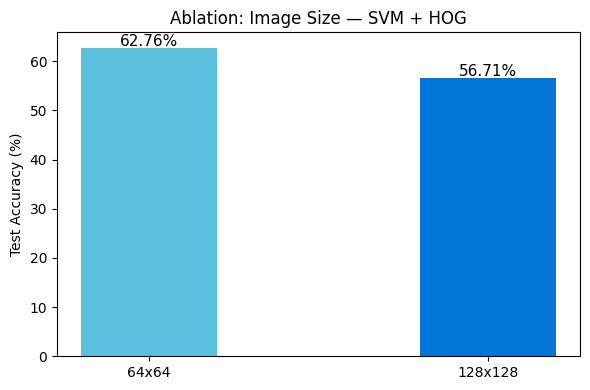

In [32]:
# ── 8. Ablation Study A: Image size 64x64 vs 128x128 ──────────────────────
from skimage.feature import hog
from skimage.color import rgb2gray

def extract_hog_custom(img_path, size):
    img = Image.open(img_path).convert("RGB").resize(size)
    img_gray = rgb2gray(np.array(img))
    return hog(img_gray, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), feature_vector=True)

def build_features(dataframe, size):
    X, y = [], []
    for _, row in dataframe.iterrows():
        X.append(extract_hog_custom(row["image_path"], size))
        y.append(row["label"])
    return np.array(X, dtype=np.float32), np.array(y)

ablation_results = {}

for img_size in [(64, 64), (128, 128)]:
    print(f"Running ablation: image size {img_size}...")
    X_tr, y_tr = build_features(train_df, img_size)
    X_te, y_te = build_features(test_df,  img_size)

    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)

    clf = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
    clf.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, clf.predict(X_te))
    ablation_results[f"{img_size[0]}x{img_size[1]}"] = acc
    print(f"  Accuracy: {acc*100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(ablation_results.keys(), [v*100 for v in ablation_results.values()],
       color=["#5bc0de", "#0275d8"], width=0.4)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Ablation: Image Size — SVM + HOG")
for i, (k, v) in enumerate(ablation_results.items()):
    ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("figures/svm_ablation_imgsize.png", dpi=150)
plt.show()

In [ ]:
# ── 9. Ablation Study B: With vs Without Data Augmentation ─────────────────
# For classical ML, "augmentation" = horizontal flips added to training set

def augment_and_extract(dataframe, size=(128, 128)):
    X, y = [], []
    for _, row in dataframe.iterrows():
        img = Image.open(row["image_path"]).convert("RGB").resize(size)

        # Original
        gray = rgb2gray(np.array(img))
        X.append(hog(gray, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), feature_vector=True))
        y.append(row["label"])

        # Flipped
        gray_flip = rgb2gray(np.array(img.transpose(Image.FLIP_LEFT_RIGHT)))
        X.append(hog(gray_flip, orientations=9, pixels_per_cell=(8,8),
                     cells_per_block=(2,2), feature_vector=True))
        y.append(row["label"])

    return np.array(X, dtype=np.float32), np.array(y)

aug_results = {}

# Without augmentation (reuse X_train_sc from step 1)
clf_no_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
clf_no_aug.fit(X_train_sc, y_train_ml)
aug_results["No Augmentation"] = accuracy_score(y_test_ml,
                                    clf_no_aug.predict(X_test_sc))

# With augmentation
print("Extracting augmented features...")
X_aug, y_aug = augment_and_extract(train_df)
sc_aug = StandardScaler()
X_aug_sc  = sc_aug.fit_transform(X_aug)
X_test_aug = sc_aug.transform(X_test_ml)

clf_aug = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
clf_aug.fit(X_aug_sc, y_aug)
aug_results["With Augmentation"] = accuracy_score(y_test_ml,
                                      clf_aug.predict(X_test_aug))

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(aug_results.keys(), [v*100 for v in aug_results.values()],
       color=["#d9534f", "#5cb85c"], width=0.4)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Ablation: Augmentation — SVM + HOG")
for i, (k, v) in enumerate(aug_results.items()):
    ax.text(i, v*100 + 0.3, f"{v*100:.2f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.savefig("figures/svm_ablation_augmentation.png", dpi=150)
plt.show()

## Model 2: ResNet-50 (Transfer Learning)

## Model 3: Vision Transformer (ViT)